In [27]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
NOTIONAL_CONTRACTS = {
    "atm_call": 1,
    "atm_put": 1,
    "otm_call": 1,
    "otm_put": 1
}

In [29]:
def import_data():
    session_signals = pd.read_csv('data/session_signals.csv')
    options_df = pd.read_csv("data/options_df.csv")
    btc_prices = pd.read_csv('data/btc_prices.csv')
    btc_prices.rename(columns={'Unnamed: 0': 'time'}, inplace=True)
    return session_signals, options_df, btc_prices

In [30]:
def construct_trades(session_signals, options_df):
    positive_signals = session_signals[session_signals['signal']]
    trades_df = options_df[options_df['session_start'].isin(positive_signals['session_start'])].copy()

    trades_df['position'] = np.select(
        [
            trades_df['leg'].str.startswith('atm'),
            trades_df['leg'].str.startswith('otm')
        ],
        ['short', 'long'],
        default=None
    )

    trades_df['contracts'] = trades_df['leg'].map(NOTIONAL_CONTRACTS)

    if trades_df['contracts'].isna().any():
        missing = trades_df.loc[trades_df['contracts'].isna(), 'leg'].unique()
        raise ValueError(f"Unmapped legs found in NOTIONAL_CONTRACTS: {missing}")

    if trades_df['position'].isna().any():
        bad = trades_df.loc[trades_df['position'].isna(), 'leg'].unique()
        raise ValueError(f"Unclassified legs: {bad}")

    cols = [
        'session_start', 'session_type', 'leg', 'strike', 'option_type',
        'position', 'entry_price', 'expiry', 'contracts'
    ]

    trades_df = trades_df[cols]
    return trades_df

In [31]:
def calculate_exit_price_and_pnl(trades_df, btc_prices):
    btc_prices_keyed = btc_prices[['time', 'close']].rename(
        columns={'time': 'expiry', 'close': 'spot_at_expiry'}
    )
    
    trades_df = trades_df.merge(
        btc_prices_keyed,
        on='expiry',
        how='left'
    )

    if trades_df['spot_at_expiry'].isna().any():
        missing = trades_df.loc[trades_df['spot_at_expiry'].isna(), 'expiry'].unique()
        raise ValueError(f"Missing BTC prices for expiries: {missing}")
    
    spot = trades_df['spot_at_expiry']
    strike = trades_df['strike']

    call_payoff = np.maximum(spot - strike, 0)
    put_payoff  = np.maximum(strike - spot, 0)

    trades_df['exit_price'] = np.select(
        [
            trades_df['option_type'] == 'C',
            trades_df['option_type'] == 'P'
        ],
        [
            call_payoff,
            put_payoff
        ],
        default=np.nan
    )

    trades_df['position_sign'] = trades_df['position'].map({'short': -1, 'long': 1})

    trades_df['pnl'] = (
        (trades_df['entry_price'] * trades_df['spot_at_expiry'] - trades_df['exit_price'])
        * trades_df['contracts']
        * trades_df['position_sign']
    )

    trades_df.drop(columns=['position_sign'], inplace=True)

    return trades_df

In [32]:
def summarise_pnl(trades_df):
    trades_df['premium_component'] = np.where(
        trades_df['position'] == 'short',
        trades_df['entry_price'],
        0
    )

    trades_df['hedge_component'] = np.where(
        trades_df['position'] == 'long',
        trades_df['entry_price'],
        0
    )

    agg = trades_df.groupby('session_start').agg(
        gross_pnl_usd=('pnl', 'sum'),
        premium_sum=('premium_component', 'sum'),
        hedge_sum=('hedge_component', 'sum'),
        spot_at_expiry=('spot_at_expiry', 'first')  # assumes constant per session
    )

    agg = agg.sort_values('session_start')

    agg['premiums_received'] = agg['premium_sum'] * agg['spot_at_expiry']
    agg['hedge_cost'] = agg['hedge_sum'] * agg['spot_at_expiry']
    agg['net_entry_premium'] = agg['premiums_received'] - agg['hedge_cost']

    agg['cumulative_pnl_usd'] = agg['gross_pnl_usd'].cumsum()

    pnl_df = agg.reset_index()[[
        'session_start',
        'gross_pnl_usd',
        'premiums_received',
        'hedge_cost',
        'net_entry_premium',
        'cumulative_pnl_usd'
    ]]
    
    return pnl_df

In [33]:
session_signals, options_df, btc_prices = import_data()

In [34]:
trades_df = construct_trades(session_signals, options_df)
trades_df = calculate_exit_price_and_pnl(trades_df, btc_prices)
trades_df

,session_start,session_type,leg,strike,option_type,position,entry_price,expiry,contracts,spot_at_expiry,exit_price,pnl
0,2025-01-13 08:00:00+00:00,weekday,atm_call,93000.0,C,short,0.0110,2025-01-14 00:00:00+00:00,1,94437.17,1437.17,398.361130
1,2025-01-13 08:00:00+00:00,weekday,atm_put,93000.0,P,short,0.0110,2025-01-14 00:00:00+00:00,1,94437.17,0.00,-1038.808870
2,2025-01-13 08:00:00+00:00,weekday,otm_call,100000.0,C,long,0.0001,2025-01-14 00:00:00+00:00,1,94437.17,0.00,9.443717
3,2025-01-13 08:00:00+00:00,weekday,otm_put,84000.0,P,long,0.0002,2025-01-14 00:00:00+00:00,1,94437.17,0.00,18.887434
4,2025-01-20 08:00:00+00:00,weekday,atm_call,108000.0,C,short,0.0215,2025-01-21 00:00:00+00:00,1,101057.33,0.00,-2172.732595
5,2025-01-20 08:00:00+00:00,weekday,atm_put,108000.0,P,short,0.0190,2025-01-21 00:00:00+00:00,1,101057.33,6942.67,5022.580730
6,2025-01-20 08:00:00+00:00,weekday,otm_call,122000.0,C,long,0.0016,2025-01-21 00:00:00+00:00,1,101057.33,0.00,161.691728
7,2025-01-20 08:00:00+00:00,weekday,otm_put,92000.0,P,long,0.0002,2025-01-21 00:00:00+00:00,1,101057.33,0.00,20.211466
8,2025-04-07 08:00:00+00:00,weekday,atm_call,76000.0,C,short,0.0230,2025-04-08 00:00:00+00:00,1,79140.01,3140.01,1319.789770
9,2025-04-07 08:00:00+00:00,weekday,atm_put,75000.0,P,short,0.0115,2025-04-08 00:00:00+00:00,1,79140.01,0.00,-910.110115


In [35]:
pnl_df = summarise_pnl(trades_df)
pnl_df

,session_start,gross_pnl_usd,premiums_received,hedge_cost,net_entry_premium,cumulative_pnl_usd
0,2025-01-13 08:00:00+00:00,-612.116589,2077.617740,28.331151,2049.286589,-612.116589
1,2025-01-20 08:00:00+00:00,3031.751329,4092.821865,181.903194,3910.918671,2419.634740
2,2025-04-07 08:00:00+00:00,504.647667,2730.330345,94.968012,2635.362333,2924.282407


#### Subtask 8

In [36]:
def compute_stats(session_signals, pnl_df):
    session_signals = session_signals.copy()
    if session_signals['session_start'].dtype == object:
        session_signals['session_start'] = pd.to_datetime(session_signals['session_start'], utc=True)

    weekend_vrp = session_signals.loc[session_signals['session_type'] == 'weekend', 'vrp'].dropna()
    weekday_vrp = session_signals.loc[session_signals['session_type'] == 'weekday', 'vrp'].dropna()

    mean_vrp_weekend = weekend_vrp.mean()
    mean_vrp_weekday = weekday_vrp.mean()

    # One-sided: is mean VRP > 0?
    t_stat_weekend, p_value_weekend = stats.ttest_1samp(weekend_vrp, 0.0, alternative='greater')
    t_stat_weekday, p_value_weekday = stats.ttest_1samp(weekday_vrp, 0.0, alternative='greater')
    # Two-sided: is weekend VRP != weekday VRP?
    t_stat_diff, p_value_diff = stats.ttest_ind(weekend_vrp, weekday_vrp, equal_var=False)

    pnl_typed = pnl_df.merge(
        session_signals[['session_start', 'session_type']].astype({'session_start': str}),
        left_on=pnl_df['session_start'].astype(str),
        right_on='session_start',
        how='left',
        suffixes=('', '_y')
    ).drop(columns=['key_0', 'session_start_y'], errors='ignore')

    def sharpe(series, ann_factor):
        s = series.dropna()
        if len(s) < 2 or s.std(ddof=1) == 0:
            return np.nan
        return s.mean() / s.std(ddof=1) * np.sqrt(ann_factor)

    weekend_pnl = pnl_typed.loc[pnl_typed['session_type'] == 'weekend', 'gross_pnl_usd']
    weekday_pnl = pnl_typed.loc[pnl_typed['session_type'] == 'weekday', 'gross_pnl_usd']

    sharpe_weekend = sharpe(weekend_pnl, 52)
    sharpe_weekday = sharpe(weekday_pnl, 104)

    stats_results = {
        'mean_vrp_weekend': mean_vrp_weekend,
        'mean_vrp_weekday': mean_vrp_weekday,
        't_stat_weekend': t_stat_weekend,
        'p_value_weekend': p_value_weekend,
        't_stat_weekday': t_stat_weekday,
        'p_value_weekday': p_value_weekday,
        't_stat_diff': t_stat_diff,
        'p_value_diff': p_value_diff,
        'sharpe_weekend': sharpe_weekend,
        'sharpe_weekday': sharpe_weekday,
    }

    print("=== VRP Statistical Analysis ===")
    print(f"n weekend sessions: {len(weekend_vrp)}, n weekday sessions: {len(weekday_vrp)}")
    print(f"Mean VRP weekend: {mean_vrp_weekend:.4f}")
    print(f"Mean VRP weekday: {mean_vrp_weekday:.4f}")
    print()
    print("One-sided one-sample t-test (H0: mean VRP <= 0, H1: mean VRP > 0):")
    print(f"  Weekend: t = {t_stat_weekend:.3f}, p = {p_value_weekend:.4f}")
    print(f"  Weekday: t = {t_stat_weekday:.3f}, p = {p_value_weekday:.4f}")
    print()
    print("Two-sided Welch t-test (H0: weekend VRP = weekday VRP):")
    print(f"  t = {t_stat_diff:.3f}, p = {p_value_diff:.4f}")
    print()
    print("Annualised Sharpe (gross_pnl_usd):")
    print(f"  Weekend (sqrt(52)):  {sharpe_weekend:.3f}  (n={len(weekend_pnl)})")
    print(f"  Weekday (sqrt(104)): {sharpe_weekday:.3f}  (n={len(weekday_pnl)})")

    return stats_results

In [37]:
stats_results = compute_stats(session_signals, pnl_df)
stats_results

=== VRP Statistical Analysis ===
n weekend sessions: 53, n weekday sessions: 53
Mean VRP weekend: -0.2421
Mean VRP weekday: 0.0432

One-sided one-sample t-test (H0: mean VRP <= 0, H1: mean VRP > 0):
  Weekend: t = -14.605, p = 1.0000
  Weekday: t = 2.846, p = 0.0032

Two-sided Welch t-test (H0: weekend VRP = weekday VRP):
  t = -12.693, p = 0.0000

Annualised Sharpe (gross_pnl_usd):
  Weekend (sqrt(52)):  nan  (n=0)
  Weekday (sqrt(104)): 5.325  (n=3)


{'mean_vrp_weekend': -0.24214300071727432,
 'mean_vrp_weekday': 0.04321140187305627,
 't_stat_weekend': -14.605304432923395,
 'p_value_weekend': 1.0,
 't_stat_weekday': 2.8458875586059293,
 'p_value_weekday': 0.0031614649862959578,
 't_stat_diff': -12.692890657840938,
 'p_value_diff': 8.38154517229979e-23,
 'sharpe_weekend': nan,
 'sharpe_weekday': 5.324771684006781}

#### Subtask 9

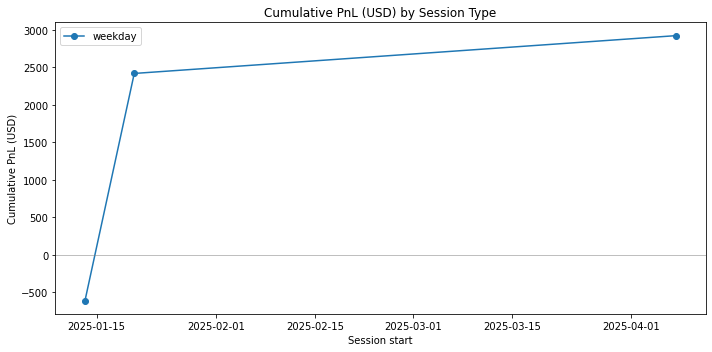

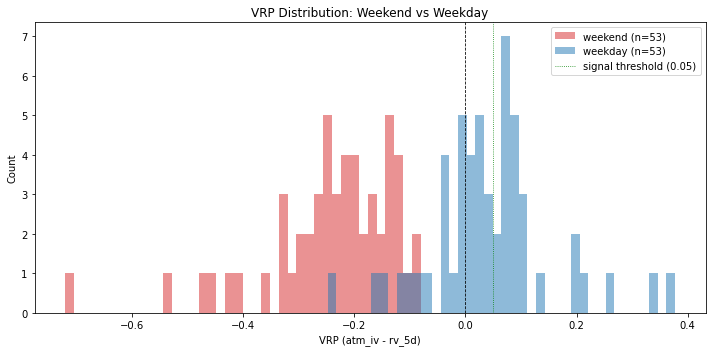

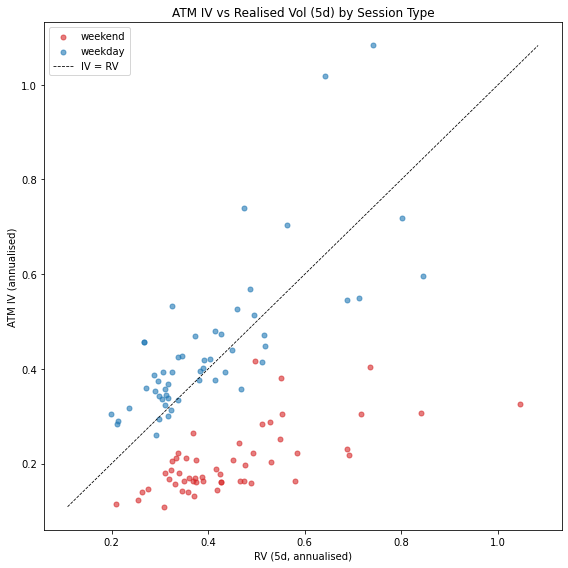

/var/folders/65/dnv7x5253c1082gl_kb1twsm0000gn/T/ipykernel_6578/166611201.py:51: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sig['month'] = sig['session_start'].dt.to_period('M').astype(str)


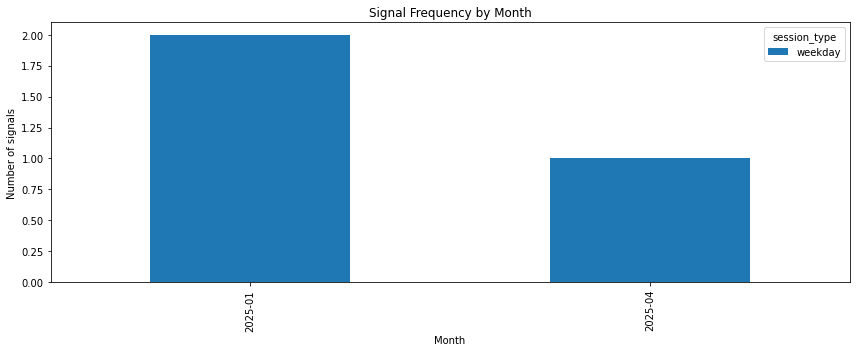

In [38]:
def make_charts(session_signals, trades_df, pnl_df):
    ss = session_signals.copy()
    ss['session_start'] = pd.to_datetime(ss['session_start'], utc=True)

    pnl = pnl_df.copy()
    pnl['session_start'] = pd.to_datetime(pnl['session_start'], utc=True)
    pnl = pnl.merge(ss[['session_start', 'session_type']], on='session_start', how='left')
    pnl = pnl.sort_values('session_start')

    palette = {'weekend': '#d62728', 'weekday': '#1f77b4'}

    # 1. Cumulative PnL (USD) by session type
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype, grp in pnl.groupby('session_type'):
        grp = grp.sort_values('session_start').copy()
        grp['cum'] = grp['gross_pnl_usd'].cumsum()
        ax.plot(grp['session_start'], grp['cum'], marker='o', label=stype, color=palette.get(stype))
    ax.set_title('Cumulative PnL (USD) by Session Type')
    ax.set_xlabel('Session start'); ax.set_ylabel('Cumulative PnL (USD)')
    ax.axhline(0, color='grey', lw=0.5); ax.legend(); fig.tight_layout()
    plt.show()

    # 2. VRP distribution histogram, weekend vs weekday overlaid
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype in ['weekend', 'weekday']:
        vals = ss.loc[ss['session_type'] == stype, 'vrp'].dropna()
        ax.hist(vals, bins=40, alpha=0.5, label=f'{stype} (n={len(vals)})', color=palette[stype])
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0.05, color='green', lw=0.8, linestyle=':', label='signal threshold (0.05)')
    ax.set_title('VRP Distribution: Weekend vs Weekday')
    ax.set_xlabel('VRP (atm_iv - rv_5d)'); ax.set_ylabel('Count')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 3. IV vs RV scatter, coloured by session type
    fig, ax = plt.subplots(figsize=(8, 8))
    for stype in ['weekend', 'weekday']:
        sub = ss[ss['session_type'] == stype]
        ax.scatter(sub['rv_5d'], sub['atm_iv'], alpha=0.6, label=stype,
                   color=palette[stype], s=25)
    lo = min(ss['rv_5d'].min(), ss['atm_iv'].min())
    hi = max(ss['rv_5d'].max(), ss['atm_iv'].max())
    ax.plot([lo, hi], [lo, hi], color='black', lw=0.8, linestyle='--', label='IV = RV')
    ax.set_title('ATM IV vs Realised Vol (5d) by Session Type')
    ax.set_xlabel('RV (5d, annualised)'); ax.set_ylabel('ATM IV (annualised)')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 4. Signal frequency by month
    sig = ss[ss['signal'].astype(bool)].copy()
    sig['month'] = sig['session_start'].dt.to_period('M').astype(str)
    counts = sig.groupby(['month', 'session_type']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 5))
    counts.plot(kind='bar', stacked=True, ax=ax,
                color=[palette.get(c, 'grey') for c in counts.columns])
    ax.set_title('Signal Frequency by Month')
    ax.set_xlabel('Month'); ax.set_ylabel('Number of signals')
    ax.legend(title='session_type'); fig.tight_layout()
    plt.show()

make_charts(session_signals, trades_df, pnl_df)

In [39]:
# CSV outputs
session_signals.to_csv('data/session_signals.csv', index=False)
trades_df.to_csv('data/trades_df.csv', index=False)
pnl_df.to_csv('data/pnl_df.csv', index=False)
print("Wrote: data/session_signals.csv, data/trades_df.csv, data/pnl_df.csv")

Wrote: data/session_signals.csv, data/trades_df.csv, data/pnl_df.csv
